ML Zoomcamp — Week 2: Regression Homework

In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Load the data**

In [82]:
df = pd.read_csv("car_fuel_efficiency_2026.csv", usecols=['engine_displacement',\
    'horsepower','vehicle_weight','model_year','fuel_efficiency_mpg'])
df.head()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0


In [83]:
df.shape

(10000, 5)

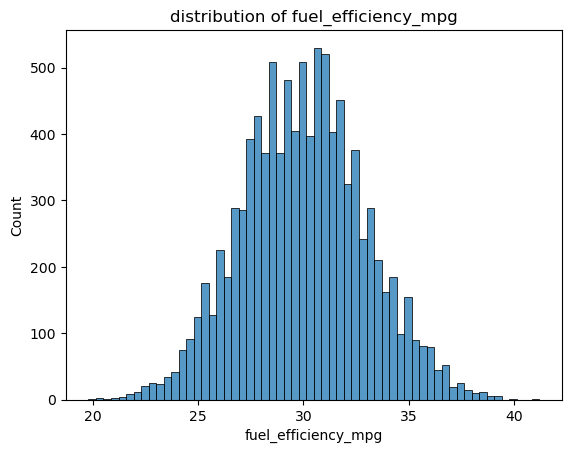

In [84]:
# Look at the fuel_efficiency_mpg variable. Does it have a long tail?
sns.histplot(df["fuel_efficiency_mpg"])
plt.title('distribution of fuel_efficiency_mpg')
plt.show()

The distribution of fuel_efficiency_mpg doesn’t have a long tail.

**Q1. There's one column with missing values. What is it?**

In [85]:
missing = df.isna().sum()
print(f"column wih missing values: {missing[missing > 0].index[0]}")

column wih missing values: horsepower


**Q2. What's the median (50% percentile) for variable 'horsepower'?**

In [86]:
print(f"median of horsepower: {df["horsepower"].median()}")

median of horsepower: 254.0


**Prepare and split the dataset**

In [87]:
n = len(df)
n_test = int(n * 0.2)
n_val = int(n * 0.2)
n_train = n - n_test - n_val

# shuffle the data
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

# split the data
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

# droping index
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

# select target feature
y_train = df_train["fuel_efficiency_mpg"]
y_test = df_test["fuel_efficiency_mpg"]
y_val = df_val["fuel_efficiency_mpg"]

# drop fuel_efficiency_mpg feature
del df_train["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]

print(f"Train: {df_train.shape[0]}, Test: {df_test.shape[0]}, Val: {df_val.shape[0]}")
print("-" * 70)
print("Train:")
print(df_train.head(3))
print("-" * 70)
print("Test:")
print(df_test.head(3))
print("-" * 70)
print("Validation:")
print(df_val.head(3))

Train: 6000, Test: 2000, Val: 2000
----------------------------------------------------------------------
Train:
   model_year  engine_displacement  horsepower  vehicle_weight
0        2015                 1900       239.0            3790
1        1992                 2000       224.0            4380
2        2022                 2330       286.0            4090
----------------------------------------------------------------------
Test:
   model_year  engine_displacement  horsepower  vehicle_weight
0        1981                 2370       268.0            4410
1        2020                 2240       256.0            4220
2        2023                 2090       217.0            3910
----------------------------------------------------------------------
Validation:
   model_year  engine_displacement  horsepower  vehicle_weight
0        2004                 2240       265.0            3990
1        2019                 2390       259.0            4770
2        2018                 2360

**Q3. We need to deal with missing values for the column from Q1.**

We have two options: fill it with 0 or with the mean of this variable.
Try both options.

For each, train a linear regression model without regularization using the code from the lessons.
For computing the mean, use the training only!
Use the validation dataset to evaluate the models and compare the RMSE of each option.
Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
Which option gives better RMSE?

In [88]:
# Train linear regression model
def LinearRegression(X_train, y_train):
    m = len(X_train)
    one = np.ones(m)
    X = np.column_stack((one, X_train))
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y_train)
    return w_full[0], w_full[1:]

# Rmse
def rmse(y, y_pred):
    se = (y- y_pred)**2
    mse = se.mean()
    return np.sqrt(mse)

# prepare data
def prepare_X(df, value):
    df = df.copy()
    df["horsepower"] = df["horsepower"].fillna(value)
    return df.values

In [89]:
mean = df_train["horsepower"].mean()

# Prepare training data
X_train_0 = prepare_X(df_train, 0)
X_train_mean = prepare_X(df_train, mean)

# Prepare validation data
X_val_0 = prepare_X(df_val, 0)
X_val_mean = prepare_X(df_val, mean)

# Fit linear regression
w0_0, w_0 = LinearRegression(X_train_0, y_train)
w0_mean, w_mean = LinearRegression(X_train_mean, y_train)

# Predictions
y_pred_0 = X_val_0.dot(w_0) + w0_0
y_pred_mean = X_val_mean.dot(w_mean) + w0_mean

# RMSE
score_0 = rmse(y_val, y_pred_0)
score_mean = rmse(y_val, y_pred_mean)

print(f"RMSE when filling with 0: {score_0:.3f}")
print(f"RMSE when filling with mean: {score_mean:.3f}")

RMSE when filling with 0: 2.205
RMSE when filling with mean: 2.202


**Q4. train a regularized linear regression.**

For this question, fill the NAs with 0. Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
Use RMSE to evaluate the model on the validation dataset. Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
Which r gives the best RMSE?

In [90]:
def LinearRegression_reg(X_train, y_train, r):
    m = len(X_train)
    one = np.ones(m)
    X = np.column_stack((one, X_train))

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y_train)

    return w_full[0], w_full[1:]

In [91]:
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

results = []

print(f"{'r':<8} {'w0':<12} {'RMSE':<10}")
print("-" * 30)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = LinearRegression_reg(X_train, y_train, r)
    y_pred = X_val.dot(w) + w0
    score = rmse(y_val, y_pred)
    results.append((r, w0, score))
    print(f"{r:<8} {w0:<12.4f} {score:<10.4f}")

best_r, best_w0, best_score = min(results, key=lambda x: x[2])

print("\nBest r:", best_r)
print("Lowest RMSE:", round(best_score, 4))

r        w0           RMSE      
------------------------------
0        -153.8850    2.2053    
0.01     -148.3092    2.2058    
0.1      -111.8387    2.2241    
1        -32.3319     2.3492    
5        -7.7729      2.4094    
10       -3.9871      2.4195    
100      -0.4082      2.4292    

Best r: 0
Lowest RMSE: 2.2053


**Q5. find out how selecting the seed influences our score.**
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

In [92]:
def train_split_test(df, seed):
    n = len(df)
    n_test = int(n * 0.2)
    n_val = int(n * 0.2)
    n_train = n - n_test - n_val

    # Shuffle the data
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    # Split the data
    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    # Select target
    y_train = df_train["fuel_efficiency_mpg"]
    y_val = df_val["fuel_efficiency_mpg"]
    y_test = df_test["fuel_efficiency_mpg"]

    # Remove target from features
    df_train = df_train.drop(columns="fuel_efficiency_mpg")
    df_val = df_val.drop(columns="fuel_efficiency_mpg")
    df_test = df_test.drop(columns="fuel_efficiency_mpg")

    return df_train, df_val, df_test, y_train, y_val, y_test

In [93]:
score = []

for i in range(10):
    df_train, df_val, df_test, y_train, y_val, y_test = train_split_test(df, i)
    X_train = prepare_X(df_train, 0)
    X_val = prepare_X(df_val, 0)
    w0, w = LinearRegression(X_train, y_train)
    y_pred = X_val.dot(w) + w0
    current_score = rmse(y_val, y_pred)
    score.append(current_score)
    print(f"Split {i} → Bias: {w0:.4f} | RMSE: {current_score:.4f}")

print(f"\nStd RMSE: {np.std(score):.3f}")

Split 0 → Bias: -150.4289 | RMSE: 2.2392
Split 1 → Bias: -151.6123 | RMSE: 2.2021
Split 2 → Bias: -152.8407 | RMSE: 2.1634
Split 3 → Bias: -152.3330 | RMSE: 2.2044
Split 4 → Bias: -158.8886 | RMSE: 2.2019
Split 5 → Bias: -151.8574 | RMSE: 2.2458
Split 6 → Bias: -154.3718 | RMSE: 2.2697
Split 7 → Bias: -155.0184 | RMSE: 2.1908
Split 8 → Bias: -150.4382 | RMSE: 2.2166
Split 9 → Bias: -154.3601 | RMSE: 2.2070

Std RMSE: 0.029


**Q6 Split the dataset like previously, use seed 9.**
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

In [96]:
df_train, df_val, df_test, y_train, y_val, y_test = train_split_test(df, 9)
X_train = prepare_X(df_train,0)
X_val = prepare_X(df_val,0)
X_test = prepare_X(df_test,0)
X_full = np.concatenate((X_train, X_val), axis=0)
y_full = np.concatenate((y_train, y_val), axis=0)
w0 , w = LinearRegression_reg(X_full, y_full,0.001 )
y_pred = X_test.dot(w) + w0
score = rmse(y_test, y_pred)
print(f"{score:.3f}")


2.236
